# `rioxarray`

In this lesson we will introduce [`rioxarray`](https://corteva.github.io/rioxarray/stable/), a Python extension for `xarray` to manipulate `xarray.DataArray`s as rasters. 

The name `rioxarray` stands for *raster input/output + xarray*. 

## About the data
The raster files we will use today come from the [US National Agriculture Imagery Program (NAIP)](https://naip-usdaonline.hub.arcgis.com). 
NAIP images are are high-resolution aerial images with four spectral bands: red (R), green (G), blue (B) and near-infrared (NIR). 
The raster's we'll use today are from 2020.

The data used in this lesson was pre-processed from a complete NAIP scene to separate the RGB bands from the NIR band and reduce the spatial extent. 
The data was accessed through [Microsoft's Planetary Computer NAIP data repository](https://planetarycomputer.microsoft.com/dataset/naip#overview).

## Import a TIF file

Let's start by loading the libraries we will use: 

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rioxarray as rioxr

There are [multiple ways of opening a TIF file using `xarray` or `rioxarray`](https://corteva.github.io/rioxarray/html/getting_started/getting_started.html). 
Using the `rioxarray.open_rasterio()` function to open the TIF file is a simple way to import the raster file as an `xarray.DataArray` and make sure all our geospatial data gets loaded correctly:

In [3]:
# Import NIR TIF file
# Make sure this is the PATH TO THE DATA FOLDER CONTAINING THE RASTERS
root = os.path.join('data', 'NAIP_SB')

In [4]:
nir = rioxr.open_rasterio(os.path.join(root, "NAIP_SB_nir.tif"))
nir

<xarray.DataArray (band: 1, y: 3208, x: 2419)> Size: 8MB
[7760152 values with dtype=uint8]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 19kB 2.512e+05 2.512e+05 ... 2.527e+05 2.527e+05
  * y            (y) float64 26kB 3.813e+06 3.813e+06 ... 3.811e+06 3.811e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [5]:
nir.values

array([[[167, 164, 161, ..., 147, 152, 151],
        [170, 170, 168, ..., 151, 149, 154],
        [176, 177, 177, ..., 151, 151, 151],
        ...,
        [ 94,  88, 101, ...,  83,  88,  79],
        [108,  95, 103, ...,  92,  91,  75],
        [ 94,  90, 104, ...,  87,  88,  82]]], dtype=uint8)

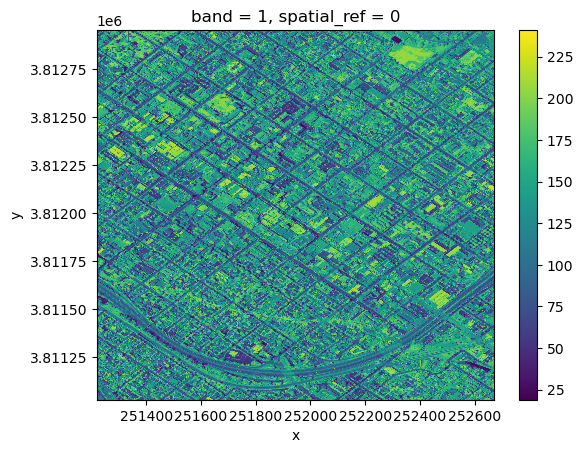

In [6]:
nir.plot()

## Drop a dimension

Our raster has an unnecessary extra dimension: band.

In [7]:
print("Size of dimension: ", dict(nir.sizes))

Size of dimension:  {'band': 1, 'y': 3208, 'x': 2419}


We can "squeeze the dimension" of length 1 by:

1. Using the `squeeze()` method. No parameters = gets rid of all dimensions of length one

2. Removing associated coordinates for this dimension using `drop()`

In [8]:
# Original dimensions and coordinates
print(nir.dims, nir.coords)

('band', 'y', 'x') Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 19kB 2.512e+05 2.512e+05 ... 2.527e+05 2.527e+05
  * y            (y) float64 26kB 3.813e+06 3.813e+06 ... 3.811e+06 3.811e+06
    spatial_ref  int64 8B 0


In [9]:
# Remove length 1 dimension (band)
nir = nir.squeeze()
print(nir.dims, '\n', nir.coords)

('y', 'x') 
 Coordinates:
    band         int64 8B 1
  * x            (x) float64 19kB 2.512e+05 2.512e+05 ... 2.527e+05 2.527e+05
  * y            (y) float64 26kB 3.813e+06 3.813e+06 ... 3.811e+06 3.811e+06
    spatial_ref  int64 8B 0


In [10]:
# Remove coordinates associated to band
nir = nir.drop_vars('band')
print(nir.dims, '\n', nir.coords)

('y', 'x') 
 Coordinates:
  * x            (x) float64 19kB 2.512e+05 2.512e+05 ... 2.527e+05 2.527e+05
  * y            (y) float64 26kB 3.813e+06 3.813e+06 ... 3.811e+06 3.811e+06
    spatial_ref  int64 8B 0


## `rio` accessor

Use the `.rio` accessor for an `xarray.DataArray` to access its rater properties.

Example:

In [12]:
# Examine raster attributes using rio accessor
print('Number of bands: ', nir.rio.count)
print('Height: ', nir.rio.height)
print('Width: ', nir.rio.width, '\n')

print('Spatial bounding box: \n', nir.rio.bounds())

print('CRS: ', nir.rio.crs)

Number of bands:  1
Height:  3208
Width:  2419 

Spatial bounding box: 
 (251218.8, 3811027.2, 252670.19999999998, 3812952.0)
CRS:  EPSG:26911


## Multi-band raster

In [14]:
# Import RGB raster
rgb = rioxr.open_rasterio(os.path.join('data', 'NAIP_SB', 'NAIP_SB_rgb.tif'))
rgb

<xarray.DataArray (band: 3, y: 3208, x: 2419)> Size: 23MB
[23280456 values with dtype=uint8]
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 19kB 2.512e+05 2.512e+05 ... 2.527e+05 2.527e+05
  * y            (y) float64 26kB 3.813e+06 3.813e+06 ... 3.811e+06 3.811e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

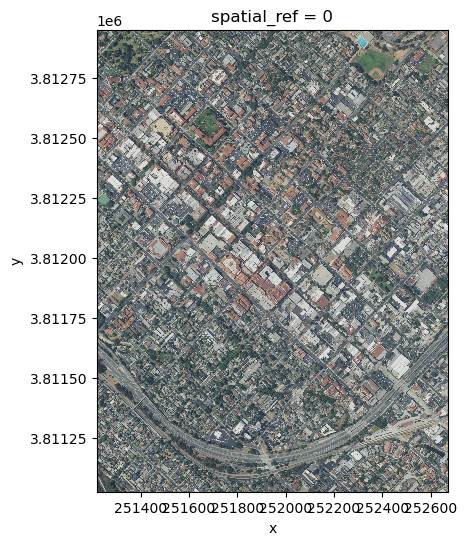

In [15]:
# Plot three bands as RGB image
rgb_aspect_ratio = rgb.rio.width / rgb.rio.height   # Raster's aspect ratio
rgb.plot.imshow(size = 6,   # Plot's height in inches
                aspect = rgb_aspect_ratio)

## Clip raster

Our area of interest (AOI) is a smaller region around NCEAS.

<Axes: >

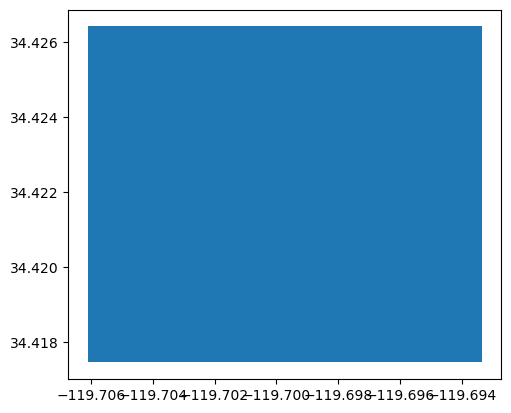

In [21]:
# Import AOI around NCEAS building
aoi = gpd.read_file(os.path.join('data', 'SB_aoi.geojson'))
aoi.plot()

In [22]:
# Examine CRSs
print('aoi CRS: ', aoi.crs)
print('nir CRS: ', nir.rio.crs)
print('rgb CRS: ', rgb.rio.crs)

aoi CRS:  EPSG:4326
nir CRS:  EPSG:26911
rgb CRS:  EPSG:26911


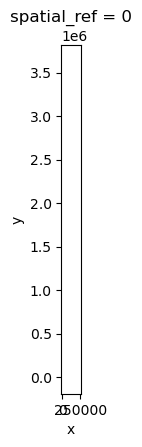

In [23]:
# Reporject AOI to RGB CRS
fig, ax = plt.subplots(figsize = (6, 6 * rgb_aspect_ratio)) # Directly set size and aspect

rgb.plot.imshow(ax = ax)
aoi.plot(ax = ax, alpha = 0.6)
plt.show()

To clip raster using the AOI polygon with the `.rio.clip_box` method

In [24]:
# Clip rasters to AOI
rgb_small = rgb.rio.clip_box(*aoi.total_bounds)
nir_small = nir.rio.clip_box(*aoi.total_bounds)

NoDataInBounds: No data found in bounds.

In [25]:
# Examine clipped data 
print('Original shape: ', nir.shape)
print('Clipped shape: ', nir_small.shape)

# Plot with correct sizes
ratio = rgb_small.rio.width / rgb_small.rio.height
rgb_small.plot.imshow(size = 4, aspect = rgb_aspect_ratio)

Original shape:  (3208, 2419)


NameError: name 'nir_small' is not defined